# Lesson 16 activity: feature engineering

## Notebook set up

Submit your notebook to the class leaderboard on HuggingFace at [huggingface.co/spaces/gperdrizet/leaderboard](https://huggingface.co/spaces/gperdrizet/leaderboard)

**Your task**: Apply at least two different feature engineering techniques to the `housing_df` dataframe to improve the dataset. At the end of the notebook, your engineered dataset and the original dataset will be used to train a linear regression model to predict `MedHouseVal`. Your goal is to achieve better model performance via feature engineering.

Don't change any of the code in the Model evaluation section of the notebook, especially the output saving. Otherwise the leaderboard scoring may not work!

Before applying transformations, explore the dataset to understand what techniques might be most beneficial.

## Notebook set-up

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler

# featurely packages the reusable helpers behind this solution; install it
# from PyPI when it is not already present in the environment
try:
    import featurely as fl

except ImportError:
    %pip install -q featurely
    import featurely as fl

# Pipeline settings selected during the staged experiments in the featurely
# repository; see notebooks 01-10 there for the scans and sweeps behind each value
DATA_URL = 'https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv'

OUTLIER_THRESHOLD = 2.25                 # IQR clip factor (notebook 02)
LOG_FEATURES = ['AveRooms', 'AveOccup']  # log1p transform targets (notebook 03)
AGG_N_BINS = 10                          # quantile bins for aggregates (notebook 07)
AGG_STATS = ('mean',)                    # bin summary statistics (notebook 07)
SMOOTH_FEATURES = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Population']  # (notebook 09)
SMOOTH_N_NEIGHBORS = 50                  # spatial smoothing neighborhood size (notebook 09)
POLY_DEGREE = 2                          # polynomial expansion degree (notebook 10)
BEST_N_COMPONENTS = 160                  # PCA components selected by CV scan (notebook 10)

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [3]:
# Load California housing dataset; keep an untouched copy for the final comparison
original_housing_df = pd.read_csv(DATA_URL)
housing_df = original_housing_df.copy()

features = [c for c in housing_df.columns if c != 'MedHouseVal']
print(f'Loaded {housing_df.shape[0]:,} rows x {housing_df.shape[1]} columns')

Loaded 20,640 rows x 9 columns


## Task 1: Explore the dataset

Before engineering anything, understand what the data looks like: scales, skew, censoring, and which features already relate to the label. Every decision in the later tasks traces back to something visible here.

Experiment notebook: [Notebook 01: EDA](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/01-EDA.ipynb).

In [4]:
# Basic structure: dtypes, non-null counts, and summary statistics
print(housing_df.info())
housing_df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


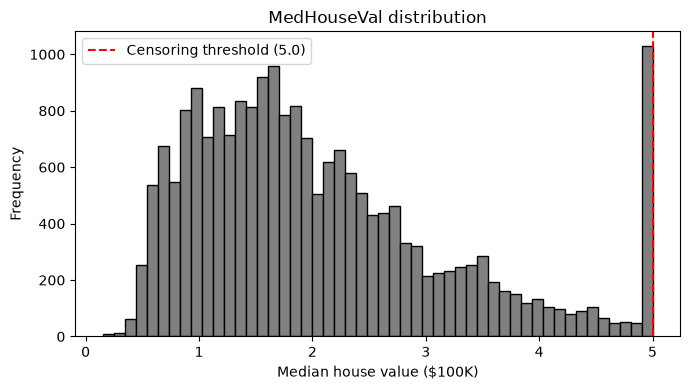

Rows at or above the 5.0 cap: 992 of 20,640 (4.8%)


In [5]:
# Label distribution: the target is right-censored at 5.0 ($500K). Districts
# whose true median exceeded the cap were recorded as exactly 5.0, which
# creates the spike at the right edge and motivates the p_censored feature.
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(housing_df['MedHouseVal'], bins=50, edgecolor='black', color='grey')
ax.axvline(5.0, color='red', linestyle='--', linewidth=1.5, label='Censoring threshold (5.0)')
ax.set_title('MedHouseVal distribution')
ax.set_xlabel('Median house value ($100K)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

n_at_cap = int((housing_df['MedHouseVal'] >= 5.0).sum())
print(f'Rows at or above the 5.0 cap: {n_at_cap:,} of {len(housing_df):,} ({n_at_cap / len(housing_df):.1%})')

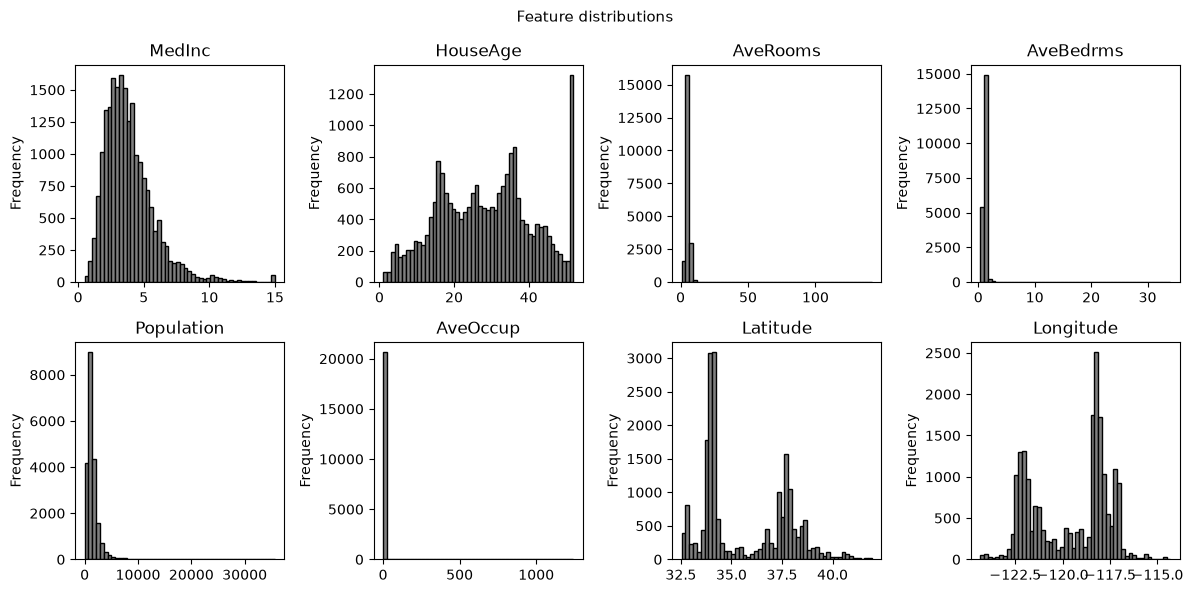

In [6]:
# Feature distributions: several features (AveRooms, AveOccup, Population)
# are heavily right-skewed with extreme outliers, motivating outlier
# clipping in Task 2 and log transforms in Task 3.
fl.plot_feature_distributions(housing_df, exclude=('MedHouseVal',))

Pearson r      Pearson p  Spearman r     Spearman p
Feature A  Feature B                                                      
AveRooms   AveBedrms    0.847621   0.000000e+00    0.082046   3.616833e-32
MedInc     AveRooms     0.326895   0.000000e+00    0.643671   0.000000e+00
AveRooms   Latitude     0.106389   5.040227e-53    0.127134   4.098513e-75
Population Longitude    0.099773   8.094076e-47    0.123527   5.518247e-71
           AveOccup     0.069863   9.319166e-24    0.242337  1.351588e-273
AveBedrms  Latitude     0.069721   1.146178e-23    0.047197   1.168895e-11
MedInc     AveOccup     0.018766   7.014583e-03   -0.044171   2.171959e-10
AveBedrms  Longitude    0.013344   5.522420e-02    0.010884   1.179095e-01
HouseAge   AveOccup     0.013191   5.807640e-02   -0.024833   3.597526e-04
           Latitude     0.011173   1.084741e-01    0.032440   3.139521e-06
MedInc     Population   0.004834   4.873722e-01    0.006268   3.678980e-01
AveOccup   Longitude    0.002476   7.220875e-01    0.181468  2.643997e-152
           Latitude     0.002366   7.339164e-01   -0.150954  1.833310e-105
AveRooms   AveOccup    -0.004852   4.857571e-01    0.018807   6.892956e-03
AveBedrms  AveOccup    -0.006181   3.745489e-01   -0.132315   2.942673e-81
MedInc     Longitude   -0.015176   2.923867e-02   -0.009928   1.537972e-01
AveRooms   Longitude   -0.027540   7.586900e-05   -0.044783   1.221511e-10
MedInc     AveBedrms   -0.062040   4.615568e-19   -0.252426  1.923590e-297
AveBedrms  Population  -0.066197   1.728435e-21    0.027027   1.030026e-04
AveRooms   Population  -0.072213   2.827077e-25   -0.105385   4.677516e-52
HouseAge   AveBedrms   -0.077747   4.779223e-29   -0.120981   3.822677e-68
MedInc     Latitude    -0.079809   1.596713e-30   -0.088029   8.593935e-37
HouseAge   Longitude   -0.108197   8.637824e-55   -0.150752  3.489000e-105
Population Latitude    -0.108785   2.267532e-55   -0.123626   4.261690e-71
MedInc     HouseAge    -0.119034   5.185138e-66   -0.147308  1.812603e-100
HouseAge   AveRooms    -0.153277  1.032422e-108   -0.231409  5.377523e-249
           Population  -0.296244   0.000000e+00   -0.283879   0.000000e+00
Latitude   Longitude   -0.924664   0.000000e+00   -0.879203   0.000000e+00

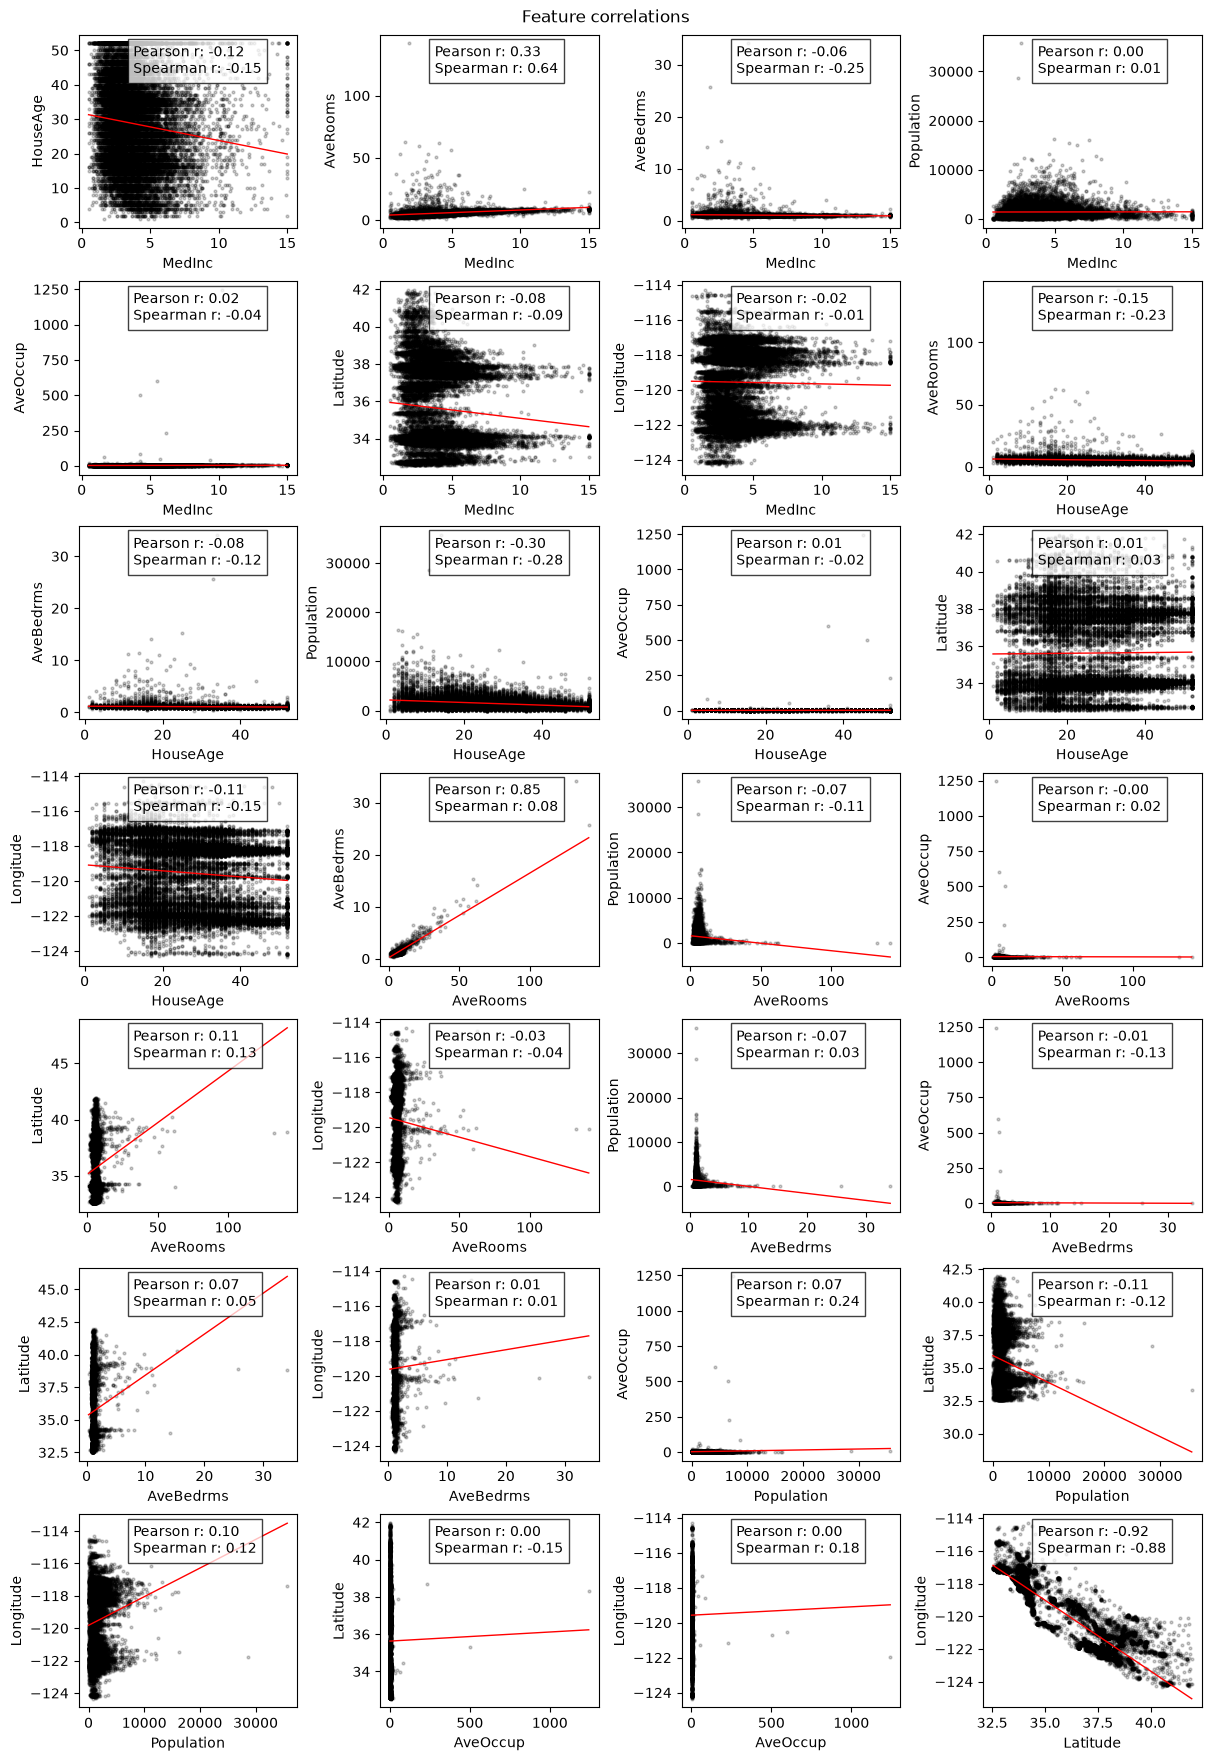

In [7]:
# Feature-feature correlations: Latitude and Longitude are strongly negatively
# correlated (the state's diagonal coastline), and room counts co-vary with
# income. Correlated pairs are candidates for interaction features.
feature_correlations_df = fl.get_feature_correlations(housing_df, features)
display(feature_correlations_df)
fl.plot_feature_correlations(housing_df, features)

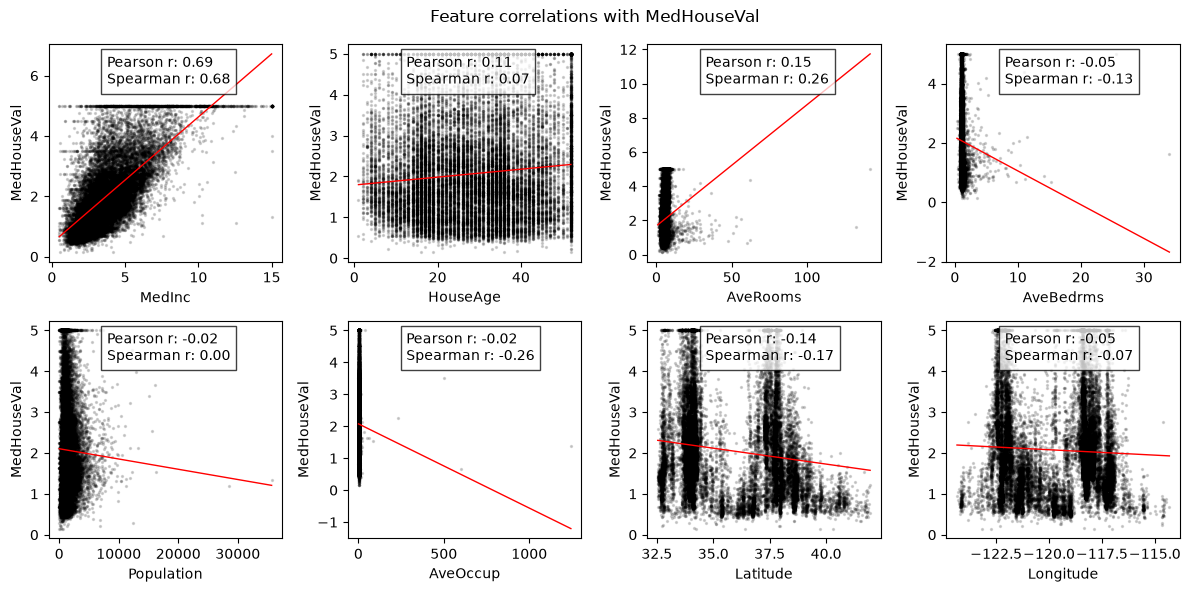

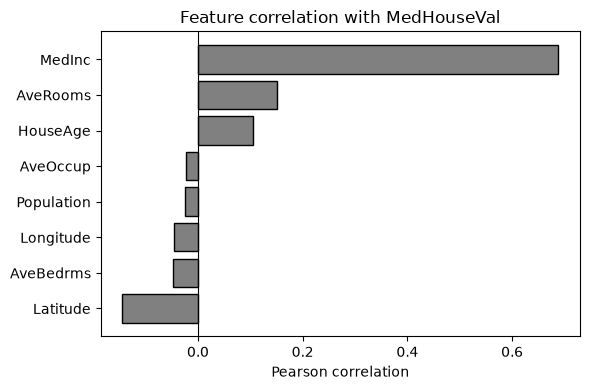

In [8]:
# Feature-label relationships: MedInc dominates; location matters but not
# linearly, which motivates the location encodings in the optional section.
fl.plot_features_vs_label(housing_df, features, label='MedHouseVal')

correlations = housing_df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title('Feature correlation with MedHouseVal')
ax.barh(correlations.index, correlations.values, color='grey', edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

## Task 2: Outlier cleaning

Notebook 02 compared ignoring, clipping, KNN imputation, and log-transforming outliers across a range of IQR thresholds, using 10-fold CV with paired t-tests. Clipping at 2.25 x IQR won: it tames extreme values without discarding rows or distorting the bulk of each distribution.

Experiment notebook: [Notebook 02: Outlier cleaning](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/02-outlier-cleaning.ipynb).

In [9]:
# Clip every feature to [Q1 - t*IQR, Q3 + t*IQR] with t selected by CV sweep
housing_df = fl.clip_outliers(housing_df, features, threshold=OUTLIER_THRESHOLD)

MedInc: Outliers clipped to [-2.34, 9.65]
HouseAge: Outliers clipped to [-24.75, 79.75]
AveRooms: Outliers clipped to [0.81, 9.68]
AveBedrms: Outliers clipped to [0.80, 1.31]
Population: Outliers clipped to [-1323.50, 3835.50]
AveOccup: Outliers clipped to [0.51, 5.20]
Latitude: Outliers clipped to [25.42, 46.22]
Longitude: Outliers clipped to [-130.33, -109.48]


## Task 3: Feature transformations

Notebook 03 scanned log, sqrt, Yeo-Johnson, and quantile-normal transforms per feature against baseline model residuals with BH FDR correction. Only the log transform of the two most skewed ratio features survived: AveRooms and AveOccup.

Experiment notebook: [Notebook 03: Feature transformations](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/03-feature-transformations.ipynb).

In [10]:
# log1p compresses the long right tails; the shift guards against negatives
for col in LOG_FEATURES:
    col_min = housing_df[col].min()
    shift = -col_min if col_min < 0 else 0
    housing_df[col] = np.log1p(housing_df[col] + shift)

print(f'Applied log1p to: {LOG_FEATURES}')

Applied log1p to: ['AveRooms', 'AveOccup']


## (Optional) Additional feature engineering

The remaining stages each earned their place through statistical gates in the staged notebooks: residual scans with BH FDR correction for individual candidates, and 10-fold CV with Holm-Bonferroni paired t-tests for grouped feature sets. Only the winners are applied here.

### Interaction features

Notebook 04 scanned all pairwise ratios and products against baseline residuals; seven passed the significance gate.

Experiment notebook: [Notebook 04: Interaction features](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/04-interaction-features.ipynb).

In [11]:
# The seven significant interactions from the notebook 04 pairwise scan,
# added in the same order to reproduce the staged pipeline exactly
interactions = {
    'ratio_HouseAge_AveOccup': housing_df['HouseAge'] / housing_df['AveOccup'],
    'ratio_AveRooms_Population': housing_df['AveRooms'] / housing_df['Population'],
    'ratio_AveRooms_AveOccup': housing_df['AveRooms'] / housing_df['AveOccup'],
    'ratio_AveBedrms_Population': housing_df['AveBedrms'] / housing_df['Population'],
    'product_MedInc_MedInc': housing_df['MedInc'] * housing_df['MedInc'],
    'product_MedInc_HouseAge': housing_df['MedInc'] * housing_df['HouseAge'],
    'product_HouseAge_Population': housing_df['HouseAge'] * housing_df['Population'],
}

housing_df = pd.concat([housing_df, pd.DataFrame(interactions, index=housing_df.index)], axis=1)
print(f'Added {len(interactions)} interaction feature(s).')

Added 7 interaction feature(s).


### Censoring probability feature

Notebook 05 built an out-of-fold probability that a row's target is censored at the 5.0 cap. Out-of-fold prediction matters: each row's probability comes from a model that never saw that row's label, which prevents direct target leakage.

Experiment notebook: [Notebook 05: Censoring probability](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/05-p_censoring.ipynb).

In [ ]:
# Binary censoring label derived from the target cap
y_censored = (housing_df['MedHouseVal'] >= 5.0).astype(int)
base_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

clf = LogisticRegression(max_iter=1000, random_state=315)

# cross_val_predict returns out-of-fold probabilities for every row
housing_df['p_censored'] = cross_val_predict(
    clf, housing_df[base_features], y_censored, cv=10, method='predict_proba'
)[:, 1]

print('Added p_censored OOF feature.')

Added p_censored OOF feature.


### Location features

Notebook 06 compared city distances, geohash cells, and rotated coordinates. Only three haversine distance features passed the gates: geohash sets did not clear the Holm-corrected CV test, and rotated coordinates are exact linear combinations of latitude and longitude, so they add nothing to a linear model.

Experiment notebook: [Notebook 06: Location feature encoding](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/06-location-feature-encoding.ipynb).

In [13]:
# Major California population centers used as distance anchors
city_coords = {
    'LosAngeles': (34.05, -118.24),
    'SanFrancisco': (37.77, -122.42),
    'SanDiego': (32.72, -117.16),
    'SanJose': (37.34, -121.89),
    'Sacramento': (38.58, -121.49),
    'Fresno': (36.74, -119.79),
}

# Compute all city distances, then keep only the three BH-significant winners
city_dist_df = fl.compute_city_distances(housing_df, cities=city_coords)
location_winners = ['dist_LosAngeles', 'dist_Fresno', 'dist_nearest_city']

housing_df = pd.concat([housing_df, city_dist_df[location_winners]], axis=1)
print(f'Added {len(location_winners)} location feature(s).')

Added 3 location feature(s).


### Aggregate features

Notebook 07 binned latitude and income into quantile bins and attached per-bin means of the other base features, giving each row context about its group. Seven candidates passed the BH FDR residual scan.

Experiment notebook: [Notebook 07: Aggregate features](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/07-aggregate-features.ipynb).

In [ ]:
# Build bin means for both driver features, then keep only the scan winners.
# Only feature columns are aggregated, so there is no target leakage.
lat_aggs = fl.compute_bin_aggregates(
    housing_df, 'Latitude', base_features[:6], n_bins=AGG_N_BINS, stats=AGG_STATS
)

inc_aggs = fl.compute_bin_aggregates(
    housing_df, 'MedInc', [c for c in base_features[:6] if c != 'MedInc'],
    n_bins=AGG_N_BINS, stats=AGG_STATS
)

aggregate_winners = [
    'Latitudebin10_mean_MedInc',
    'Latitudebin10_mean_HouseAge',
    'Latitudebin10_mean_AveRooms',
    'Latitudebin10_mean_AveBedrms',
    'Latitudebin10_mean_Population',
    'MedIncbin10_mean_Population',
    'MedIncbin10_mean_AveOccup',
]

all_aggs = pd.concat([lat_aggs, inc_aggs], axis=1)
housing_df = pd.concat([housing_df, all_aggs[aggregate_winners]], axis=1)
print(f'Added {len(aggregate_winners)} aggregate feature(s).')

Added 7 aggregate feature(s).


### Spatial smoothing

Notebook 09 smoothed selected features with a Gaussian kernel over each row's 50 nearest spatial neighbors, exposing neighborhood-level context that block-level values hide. Adding the smoothed columns alongside the originals beat both the baseline and full replacement, and this stage produced the single largest gain in the pipeline. Notebook 08's k-means cluster features are skipped entirely: no cluster set passed its significance gate.

Experiment notebooks: [Notebook 08: Clustering](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/08-clustering.ipynb) and [Notebook 09: Smoothing](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/09-smoothing.ipynb).

In [ ]:
# Gaussian-kernel weighted neighborhood averages; bandwidth adapts to local
# point density. Feature values only, never the target.
smoothed_df = fl.compute_spatial_smoothed(
    housing_df, SMOOTH_FEATURES, n_neighbors=SMOOTH_N_NEIGHBORS
)

housing_df = pd.concat([housing_df, smoothed_df], axis=1)
print(f'Added {smoothed_df.shape[1]} smoothed feature(s) alongside originals.')

Using adaptive bandwidth: 0.0361 degrees
Added 5 smoothed feature(s) alongside originals.


### Polynomial features and PCA

Notebook 10 expanded the feature set to all degree-2 terms, then rotated it with PCA and selected the component count by cross-validated R². The winning configuration keeps the first 160 components: enough to capture the useful interaction structure while discarding the noisiest directions.

Experiment notebook: [Notebook 10: Polynomial features and PCA](https://github.com/gperdrizet/featurely/blob/main/example_notebooks/fsa-feature-engineering-challenge/10-polyfeatures-pca.ipynb).

In [ ]:
# Degree-2 expansion of every feature column (all are continuous at this point)
feature_cols = [c for c in housing_df.columns if c != 'MedHouseVal']
poly_df = fl.make_polynomial_features(housing_df, feature_cols, degree=POLY_DEGREE)
print(f'Expanded {len(feature_cols)} features to {poly_df.shape[1]} polynomial terms.')

# Scale, rotate with PCA, and keep the CV-selected component count
x_scaled = StandardScaler().fit_transform(poly_df)
components = PCA(n_components=BEST_N_COMPONENTS).fit_transform(x_scaled)

med_house_val = housing_df['MedHouseVal'].values

housing_df = pd.DataFrame(
    components,
    columns=[f'PC{i + 1}' for i in range(BEST_N_COMPONENTS)],
    index=housing_df.index,
)

housing_df['MedHouseVal'] = med_house_val
print(f'Final frame: {housing_df.shape[0]} rows x {housing_df.shape[1]} columns')

Expanded 31 features to 527 polynomial terms.
Final frame: 20640 rows x 161 columns


## Model evaluation

Compare model performance on the original dataset versus the engineered dataset, using the same 10-fold cross-validation as the staged pipeline.

### Evaluate datasets

In [ ]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [18]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 39.03%


### Visualize model performance comparison

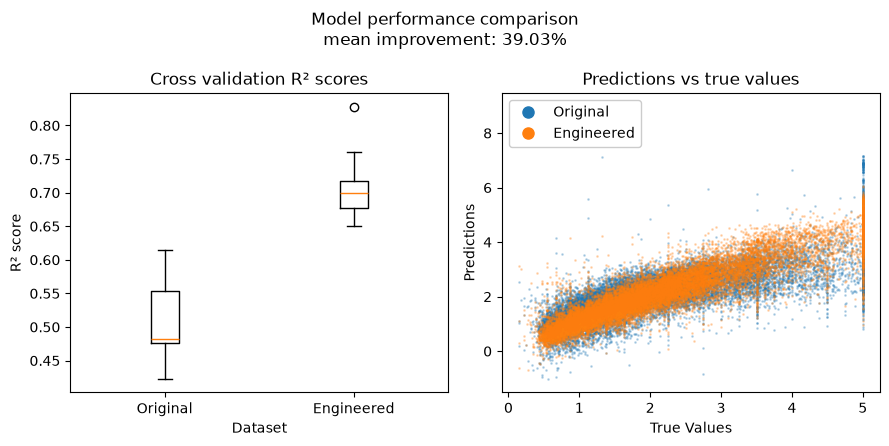

In [19]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R² scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R² score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()